## Six month long Bitcoin data (per hour)

In [ ]:
import requests
import pandas as pd
from datetime import datetime, timedelta
import time

coin_id = "bitcoin"
vs_currency = "usd"
interval = "hourly"

# number of months
months = 6
all_data = []

for i in range(months):
    # start_days = how many days ago
    start_days = (i+1)*30
    end_days = i*30
    # CoinGecko 'days' param accepts "30", "60", etc.
    # We'll take 30 day chunks sequentially
    url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
    params = {
        "vs_currency": vs_currency,
        "days": 30,  # 30 days per chunk
        "interval": interval
    }
    response = requests.get(url, params=params)
    chunk = response.json()
    prices = chunk['prices']
    df_chunk = pd.DataFrame(prices, columns=["timestamp_ms", "current_price"])
    df_chunk["timestamp"] = pd.to_datetime(df_chunk["timestamp_ms"], unit="ms")
    df_chunk = df_chunk[["timestamp", "current_price"]]

    # append to list
    all_data.append(df_chunk)

    print(f"Chunk {i+1} done, rows: {df_chunk.shape[0]}")

    # sleep 1 sec to avoid rate limit
    time.sleep(1)

# concatenate all chunks
full_df = pd.concat(all_data)
full_df = full_df.sort_values("timestamp").reset_index(drop=True)

# save CSV
full_df.to_csv("bitcoin_6months_hourly.csv", index=False)
print("All 6 months downloaded:", full_df.shape)

Chunk 1 done, rows: 722
Chunk 2 done, rows: 722
Chunk 3 done, rows: 722
Chunk 4 done, rows: 722
Chunk 5 done, rows: 722
Chunk 6 done, rows: 722
All 6 months downloaded: (4332, 2)


## first *code* attempt

Timestamp monotonic: True
Price min/max: 62905.750100773046 75632.41015615774
Any missing values: 0


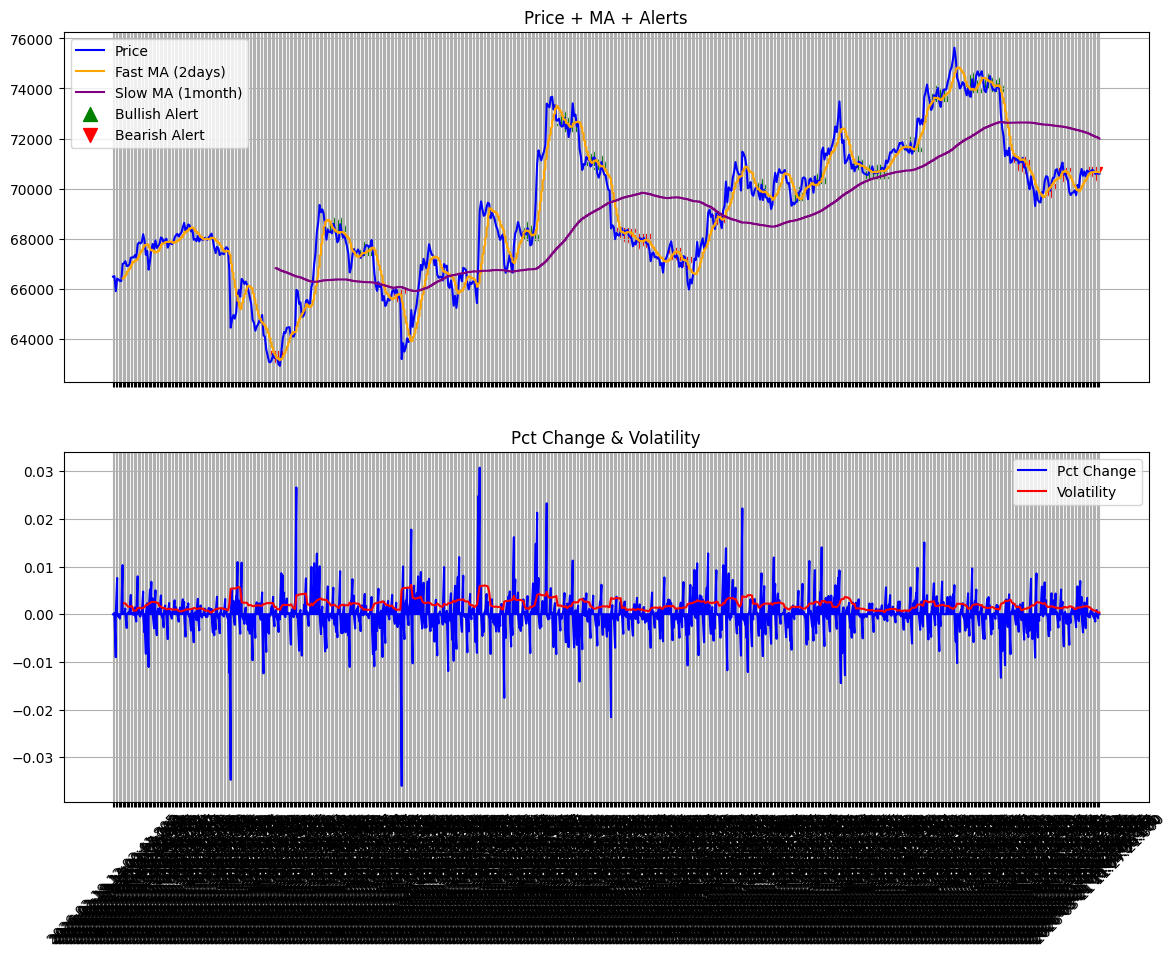

=== Alert Summary Table ===


,Alert Type,Count,Avg Volatility,Avg Price Change % (next hour)
0,Bullish,26,0.001420,0.003259
1,Bearish,14,0.001268,0.008681


In [14]:
from numpy import sin
import requests
import pandas as pd
from datetime import datetime, timedelta
import time

#sim_df = full_df.copy()
sim_df = pd.read_csv("/content/bitcoin_6months_hourly.csv")
# ==============================
#  Sanity Checks
# ==============================
print("Timestamp monotonic:", sim_df["timestamp"].is_monotonic_increasing)
print("Price min/max:", sim_df["current_price"].min(), sim_df["current_price"].max())
print("Any missing values:", sim_df.isna().sum().sum())
# ==============================
#  PREPROCESSING
# ==============================
# price_diff & pct_change
sim_df["price_diff"] = sim_df["current_price"].diff()
sim_df["pct_change"] = sim_df["current_price"].pct_change()

# Moving averages
sim_df["fast_MA"] = sim_df["current_price"].rolling(window=48).mean() # 2 dys smoothing
sim_df["slow_MA"] = sim_df["current_price"].rolling(window=720).mean() #1 month smoothing

# Volatility (std of pct_change)
sim_df["volatility"] = sim_df["pct_change"].rolling(window=48).std()

# ==============================
# CROSSOVER ALERT LOGIC
# ==============================
# previous price for crossover detection
sim_df["price_prev"] = sim_df["current_price"].shift(1)
sim_df["fast_MA_prev"] = sim_df["fast_MA"].shift(1)

# determine bullish / bearish alerts
sim_df["alert_type"] = None

# conditions
bullish_cond = (
    (sim_df["price_prev"] < sim_df["fast_MA_prev"]) &
    (sim_df["current_price"] > sim_df["fast_MA"]) &
    (sim_df["fast_MA"] > sim_df["slow_MA"]) &
    (sim_df["volatility"] < sim_df["volatility"].mean())
)

bearish_cond = (
    (sim_df["price_prev"] > sim_df["fast_MA_prev"]) &
    (sim_df["current_price"] < sim_df["fast_MA"]) &
    (sim_df["fast_MA"] < sim_df["slow_MA"]) &
    (sim_df["volatility"] < sim_df["volatility"].mean())
)

sim_df.loc[bullish_cond, "alert_type"] = "Bullish"
sim_df.loc[bearish_cond, "alert_type"] = "Bearish"

# ==============================
#  VISUALIZATION
# ==============================
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(14,10), sharex=True)

# Top: Price + MA + Alerts
ax1.plot(sim_df["timestamp"], sim_df["current_price"], label="Price", color="blue")
ax1.plot(sim_df["timestamp"], sim_df["fast_MA"], label="Fast MA (2days)", color="orange")
ax1.plot(sim_df["timestamp"], sim_df["slow_MA"], label="Slow MA (1month)", color="purple")

# scatter alerts
bullish = sim_df[sim_df["alert_type"]=="Bullish"]
bearish = sim_df[sim_df["alert_type"]=="Bearish"]

ax1.scatter(bullish["timestamp"], bullish["current_price"], label="Bullish Alert", color="green", marker="^", s=100)
ax1.scatter(bearish["timestamp"], bearish["current_price"], label="Bearish Alert", color="red", marker="v", s=100)

ax1.set_title("Price + MA + Alerts")
ax1.legend()
ax1.grid(True)

# Bottom: pct_change + volatility
ax2.plot(sim_df["timestamp"], sim_df["pct_change"], label="Pct Change", color="blue")
ax2.plot(sim_df["timestamp"], sim_df["volatility"], label="Volatility", color="red")
ax2.set_title("Pct Change & Volatility")
ax2.legend()
ax2.grid(True)

plt.xticks(rotation=45)
plt.show()


# ==============================
#  EXPORT ALERTS
# ==============================
alerts_df = sim_df[sim_df["alert_type"].notnull()]
alerts_df.to_csv("crypto_alerts.csv", index=False)


sim_df.to_csv("full_df_with_alerts.csv", index=False)
# ==============================
# Summary Stats Table
# ==============================

summary_table = pd.DataFrame({
    "Alert Type": ["Bullish", "Bearish"],
    "Count": [alerts_df[alerts_df["alert_type"]=="Bullish"].shape[0],
              alerts_df[alerts_df["alert_type"]=="Bearish"].shape[0]],
    "Avg Volatility": [alerts_df[alerts_df["alert_type"]=="Bullish"]["volatility"].mean(),
                       alerts_df[alerts_df["alert_type"]=="Bearish"]["volatility"].mean()],
    "Avg Price Change % (next hour)": [
        alerts_df[alerts_df["alert_type"]=="Bullish"]["current_price"].pct_change().shift(-1).mean(),
        alerts_df[alerts_df["alert_type"]=="Bearish"]["current_price"].pct_change().shift(-1).mean()
    ]
})

print("=== Alert Summary Table ===")
display(summary_table)


## second code attemp (**curenly using this one**)






Timestamp monotonic: True
Price min/max: 62905.750100773046 75632.41015615774
Any missing values: 0


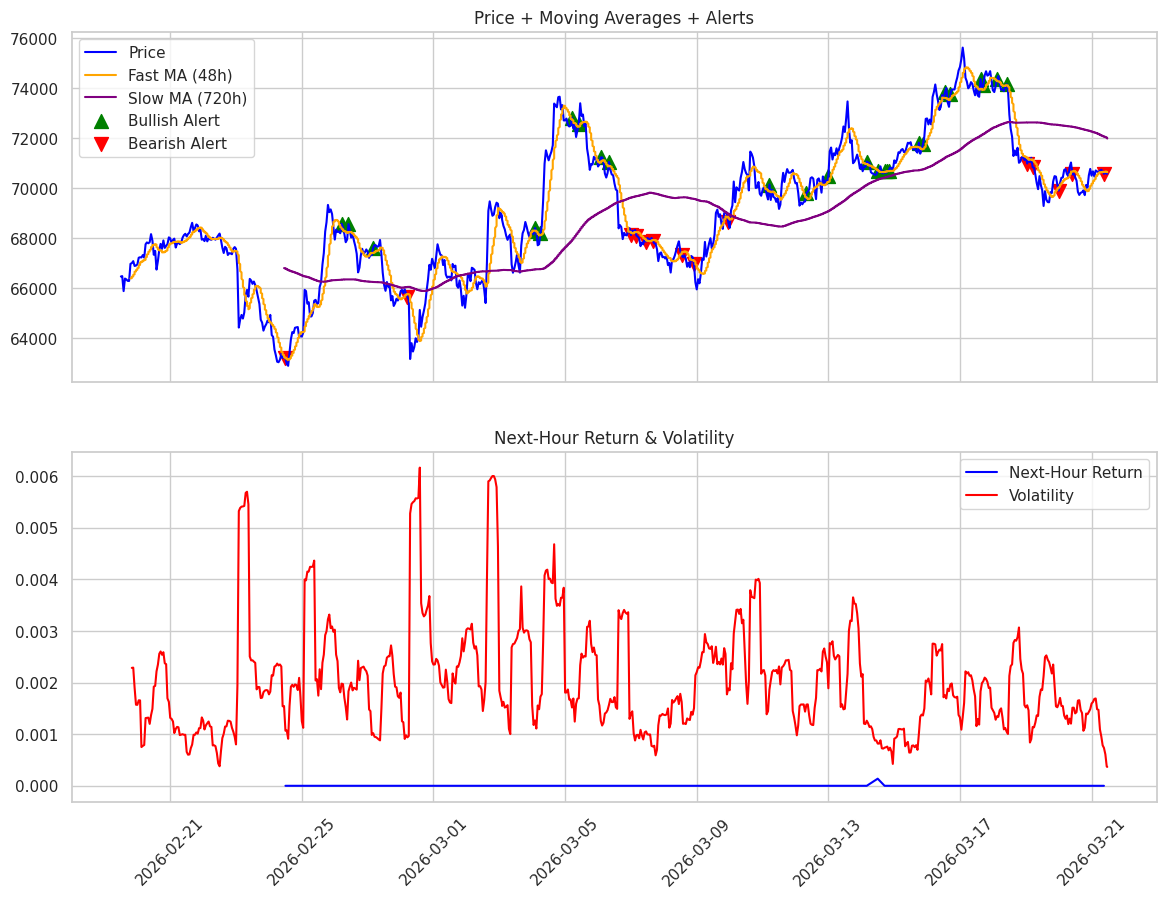

=== Alert Summary Table ===


,Alert Type,Count,Avg Volatility,Avg Next-Hour Return %
0,Bullish,26,0.001420,0.000531
1,Bearish,14,0.001268,0.000000


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# ==============================
# 1️⃣ Load data
# ==============================
sim_df = pd.read_csv("/content/bitcoin_6months_hourly.csv")

# Convert timestamp to datetime for accurate plotting & sorting
sim_df['timestamp'] = pd.to_datetime(sim_df['timestamp'])

# ==============================
# 2️⃣ Sanity checks
# ==============================
print("Timestamp monotonic:", sim_df["timestamp"].is_monotonic_increasing)
print("Price min/max:", sim_df["current_price"].min(), sim_df["current_price"].max())
print("Any missing values:", sim_df.isna().sum().sum())

# ==============================
# 3️⃣ Preprocessing
# ==============================

# Compute price difference & % change
sim_df["price_diff"] = sim_df["current_price"].diff()
sim_df["pct_change"] = sim_df["current_price"].pct_change()

# Moving averages for trend/alerts
sim_df["fast_MA"] = sim_df["current_price"].rolling(window=48).mean()  # 2-day smoothing
sim_df["slow_MA"] = sim_df["current_price"].rolling(window=720).mean() # 1-month smoothing

# Volatility as rolling std of pct_change
sim_df["volatility"] = sim_df["pct_change"].rolling(window=48).std()

# ==============================
# 4️⃣ Cross-over alert logic
# ==============================

# Shifted columns to detect crossover
sim_df["price_prev"] = sim_df["current_price"].shift(1)
sim_df["fast_MA_prev"] = sim_df["fast_MA"].shift(1)

# Initialize alert column
sim_df["alert_type"] = None

# Bullish condition:
# 1. Previous price < previous fast MA → price is below short-term trend
# 2. Current price > current fast MA → price crossed above short-term trend
# 3. Fast MA > slow MA → general uptrend
# 4. Volatility is below average → avoid noisy periods
bullish_cond = (
    (sim_df["price_prev"] < sim_df["fast_MA_prev"]) &
    (sim_df["current_price"] > sim_df["fast_MA"]) &
    (sim_df["fast_MA"] > sim_df["slow_MA"]) &
    (sim_df["volatility"] < sim_df["volatility"].mean(skipna=True))
)

# Bearish condition: opposite logic
bearish_cond = (
    (sim_df["price_prev"] > sim_df["fast_MA_prev"]) &
    (sim_df["current_price"] < sim_df["fast_MA"]) &
    (sim_df["fast_MA"] < sim_df["slow_MA"]) &
    (sim_df["volatility"] < sim_df["volatility"].mean(skipna=True))
)

# Assign alerts
sim_df.loc[bullish_cond, "alert_type"] = "Bullish"
sim_df.loc[bearish_cond, "alert_type"] = "Bearish"

# ==============================
# 5️⃣ Compute next-hour return (CORRECT)
# ==============================

# Shift current_price in full df by -1 to get the "next hour price"
sim_df["next_price"] = sim_df["current_price"].shift(-1)

# Compute actual return after alert
sim_df["next_hour_return"] = (sim_df["next_price"] - sim_df["current_price"]) / sim_df["current_price"]

# Extract only rows where alert exists
alerts_df = sim_df[sim_df["alert_type"].notnull()].copy()

# ==============================
# 6️⃣ Cumulative return & win/loss flag
# ==============================
alerts_df["cumulative_return"] = (1 + alerts_df["next_hour_return"]).cumprod()
alerts_df["win"] = alerts_df["next_hour_return"] > 0

# ==============================
# 7️⃣ Visualization
# ==============================

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(14,10), sharex=True)

# Top: Price + Moving Averages + Alerts
ax1.plot(sim_df["timestamp"], sim_df["current_price"], label="Price", color="blue")
ax1.plot(sim_df["timestamp"], sim_df["fast_MA"], label="Fast MA (48h)", color="orange")
ax1.plot(sim_df["timestamp"], sim_df["slow_MA"], label="Slow MA (720h)", color="purple")

# Scatter alerts
bullish = alerts_df[alerts_df["alert_type"]=="Bullish"]
bearish = alerts_df[alerts_df["alert_type"]=="Bearish"]
ax1.scatter(bullish["timestamp"], bullish["current_price"], label="Bullish Alert", color="green", marker="^", s=100)
ax1.scatter(bearish["timestamp"], bearish["current_price"], label="Bearish Alert", color="red", marker="v", s=100)

ax1.set_title("Price + Moving Averages + Alerts")
ax1.legend()
ax1.grid(True)

# Bottom: Next-hour return & volatility
ax2.plot(alerts_df["timestamp"], alerts_df["next_hour_return"], label="Next-Hour Return", color="blue")
ax2.plot(sim_df["timestamp"], sim_df["volatility"], label="Volatility", color="red")
ax2.set_title("Next-Hour Return & Volatility")
ax2.legend()
ax2.grid(True)

plt.xticks(rotation=45)
plt.show()

# ==============================
# 8️⃣ Export alerts
# ==============================
alerts_df.to_csv("crypto_alerts_correct.csv", index=False)
sim_df.to_csv("full_df_with_alerts_correct.csv", index=False)

# ==============================
# 9️⃣ Summary table
# ==============================
summary_table = pd.DataFrame({
    "Alert Type": ["Bullish", "Bearish"],
    "Count": [
        alerts_df[alerts_df["alert_type"]=="Bullish"].shape[0],
        alerts_df[alerts_df["alert_type"]=="Bearish"].shape[0]
    ],
    "Avg Volatility": [
        alerts_df[alerts_df["alert_type"]=="Bullish"]["volatility"].mean(),
        alerts_df[alerts_df["alert_type"]=="Bearish"]["volatility"].mean()
    ],
    "Avg Next-Hour Return %": [
        alerts_df[alerts_df["alert_type"]=="Bullish"]["next_hour_return"].mean()*100,
        alerts_df[alerts_df["alert_type"]=="Bearish"]["next_hour_return"].mean()*100
    ]
})

print("=== Alert Summary Table ===")
display(summary_table)

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/content/full_df_with_alerts.csv")


## Vectorized **merge_asof** solution for performance metrics.

Computed 24-hour forward returns using time-aligned, vectorized nearest-neighbor merges on timestamped alerts, handling edge cases without Python loops.

In [47]:
import pandas as pd
import numpy as np

# ----------------------------
# PARAMETERS
# ----------------------------
n_hours = 24  # time window for return calculation

# ----------------------------
# 1️⃣ Ensure timestamps are datetime
# ----------------------------
alerts_df['timestamp'] = pd.to_datetime(alerts_df['timestamp'])
df['timestamp'] = pd.to_datetime(df['timestamp'])

# ----------------------------
# 2️⃣ Sort both dataframes by timestamp (required for merge_asof)
# ----------------------------
alerts_df = alerts_df.sort_values('timestamp').copy()
df = df.sort_values('timestamp').copy()

# ----------------------------
# 3️⃣ Create target timestamps (alert time + 24h)
# ----------------------------
alerts_df['target_time'] = alerts_df['timestamp'] + pd.Timedelta(hours=n_hours)

# ----------------------------
# 4️⃣ Merge to find first future price at or after target_time
# ----------------------------
# merge_asof works like a "nearest neighbor in time"
# direction='forward' ensures we pick the first price >= target_time
alerts_with_future = pd.merge_asof(
    alerts_df,
    df[['timestamp', 'current_price']].rename(columns={'timestamp':'future_time',
                                                       'current_price':'future_price'}),
    left_on='target_time',
    right_on='future_time',
    direction='forward'
)

# ----------------------------
# 5️⃣ Fill missing future prices with last available price
# This handles alerts that are near the end of df and have no row 24h ahead
# ----------------------------
alerts_with_future['future_price'] = alerts_with_future['future_price'].fillna(df['current_price'].iloc[-1])

# ----------------------------
# 6️⃣ Calculate 24-hour return
# ----------------------------
alerts_with_future['return'] = (alerts_with_future['future_price'] -
                                alerts_with_future['current_price']) / alerts_with_future['current_price']

# ----------------------------
# 7️⃣ Assign back to original alerts_df
# Use .values to ignore index alignment issues
# ----------------------------
alerts_df['return'] = alerts_with_future['return'].values

# ----------------------------
# 8️⃣ Optional: drop temporary column if you want clean df
# ----------------------------
alerts_df.drop(columns=['target_time'], inplace=True)

# ----------------------------
# ✅ alerts_df now has a correct 'return' column
# ----------------------------

In [41]:
alerts_df.head()

,timestamp,current_price,price_diff,pct_change,fast_MA,slow_MA,volatility,price_prev,fast_MA_prev,alert_type,return
720,2026-02-24 12:03:34.966,63207.593482,-68.662226,-0.001085,63246.516574,66808.863849,0.001068,63276.255708,63253.858228,Bearish,0.045143
966,2026-02-26 05:00:24.028,68588.065608,379.540258,0.005564,68441.135563,66346.926788,0.001980,68208.525351,68453.085043,Bullish,-0.012421
996,2026-02-26 10:03:11.397,68571.598793,614.320333,0.009040,68224.540514,66360.919247,0.001833,67957.278460,68218.053284,Bullish,-0.017540
1104,2026-02-27 04:03:17.716,67617.937989,287.345526,0.004268,67418.044807,66260.316233,0.001020,67330.592463,67417.356066,Bullish,-0.027061
1254,2026-02-28 05:03:02.782,65662.794396,-125.351738,-0.001905,65764.287247,66055.083119,0.000939,65788.146134,65762.740160,Bearish,0.025706


In [48]:
mean_return = alerts_df['return'].mean()

win_rate = (alerts_df['return'] > 0).mean()

print(f"Mean return: {mean_return:.4%}")
print(f"Win rate: {win_rate:.2%}")


Mean return: 0.1408%
Win rate: 52.50%


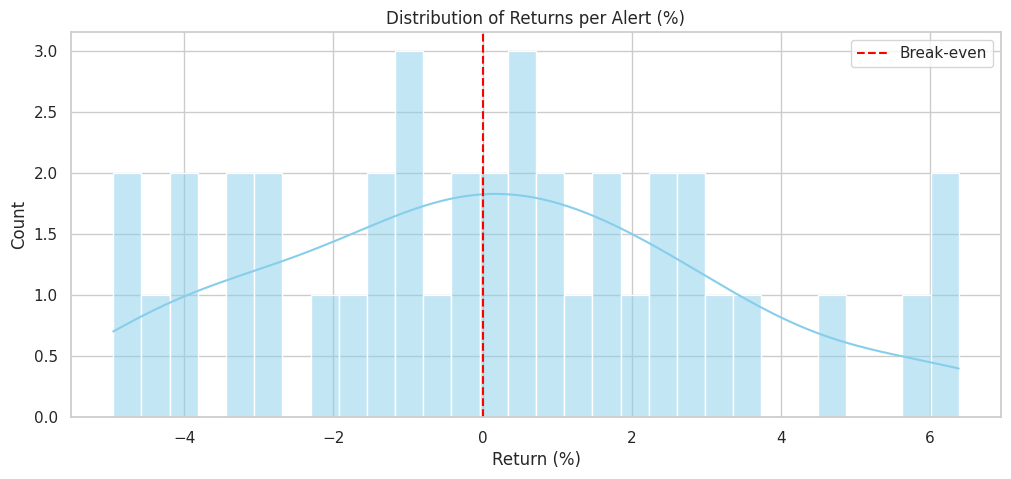

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Plot all alert returns
plt.figure(figsize=(12,5))
sns.histplot(alerts_df['return']*100, bins=30, kde=True, color='skyblue')
plt.axvline(0, color='red', linestyle='--', label='Break-even')
plt.title('Distribution of Returns per Alert (%)')
plt.xlabel('Return (%)')
plt.ylabel('Count')
plt.legend()
plt.show()

## At this point the alert system has a win rate of 52.5% and a mean return of 0.14% per alert.This indicates that although not all alerts succeed, the system is slightly profitable on average and demonstrates predictive value for short-term price movements.

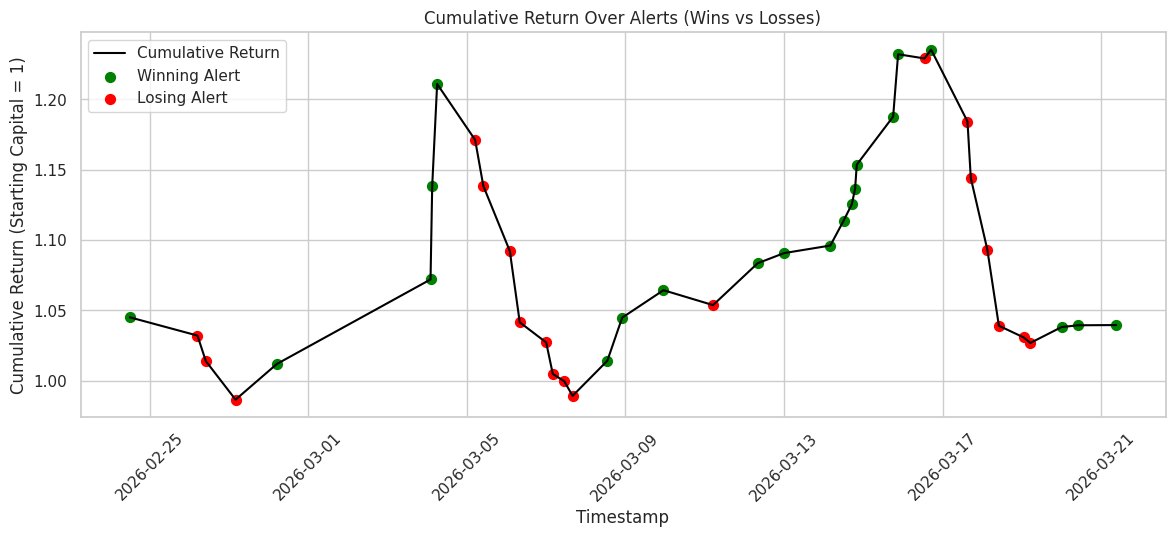

In [50]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure alerts are chronological
alerts_df = alerts_df.sort_values('timestamp').reset_index(drop=True)

# Cumulative return
alerts_df['cumulative_return'] = (1 + alerts_df['return']).cumprod()

# Mark winning vs losing alerts
alerts_df['win'] = alerts_df['return'] > 0

# Plot
plt.figure(figsize=(14,5))

# Plot line for cumulative return
plt.plot(alerts_df['timestamp'], alerts_df['cumulative_return'], color='black', label='Cumulative Return')

# Overlay scatter for wins
plt.scatter(alerts_df.loc[alerts_df['win'], 'timestamp'],
            alerts_df.loc[alerts_df['win'], 'cumulative_return'],
            color='green', label='Winning Alert', s=50)

# Overlay scatter for losses
plt.scatter(alerts_df.loc[~alerts_df['win'], 'timestamp'],
            alerts_df.loc[~alerts_df['win'], 'cumulative_return'],
            color='red', label='Losing Alert', s=50)

plt.title('Cumulative Return Over Alerts (Wins vs Losses)')
plt.xlabel('Timestamp')
plt.ylabel('Cumulative Return (Starting Capital = 1)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [51]:
# ==============================
# Define trend based on long-term MA
# ==============================
alerts_df['trend'] = alerts_df['fast_MA'] > alerts_df['slow_MA']  # True = Uptrend

# Define volatility groups (median split)
vol_median = alerts_df['volatility'].median()
alerts_df['vol_group'] = alerts_df['volatility'] <= vol_median  # True = Low Vol, False = High Vol

# ==============================
# Group by trend and volatility
# ==============================
grouped = alerts_df.groupby(['trend','vol_group'])

summary_by_condition = grouped['next_hour_return'].agg(
    mean_return='mean',
    win_rate=lambda x: (x>0).mean(),
    max_drawdown=lambda x: x.min(),
    count='count'
).reset_index()

# Rename for readability
summary_by_condition['trend'] = summary_by_condition['trend'].map({True:'Uptrend', False:'Downtrend'})
summary_by_condition['vol_group'] = summary_by_condition['vol_group'].map({True:'Low Vol', False:'High Vol'})

# Show table
print("=== Alert Performance by Trend & Volatility ===")
display(summary_by_condition)

=== Alert Performance by Trend & Volatility ===


,trend,vol_group,mean_return,win_rate,max_drawdown,count
0,Downtrend,High Vol,0.000000,0.000000,0.0,7
1,Downtrend,Low Vol,0.000000,0.000000,0.0,7
2,Uptrend,High Vol,0.000000,0.000000,0.0,13
3,Uptrend,Low Vol,0.000011,0.076923,0.0,13


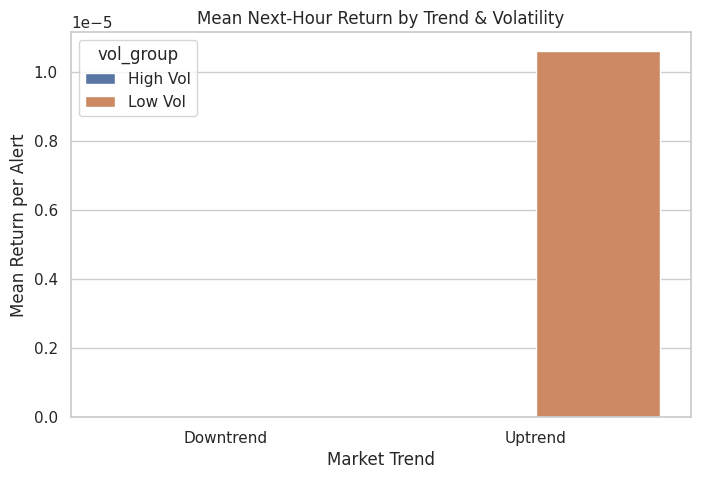

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x='trend', y='mean_return', hue='vol_group', data=summary_by_condition)
plt.title('Mean Next-Hour Return by Trend & Volatility')
plt.ylabel('Mean Return per Alert')
plt.xlabel('Market Trend')
plt.show()

Counts are small; results are illustrative. For real evaluation, more data or slightly looser thresholds would provide more meaningful statistics.

---

# This is a script to generate a final report

In [53]:
# ==========================================
# README Generator for Crypto Alert Portfolio
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --------------------------
# 1️⃣ Load data
# --------------------------
full_df_path = "full_df_with_alerts_correct.csv"
alerts_df_path = "crypto_alerts_correct.csv"

full_df = pd.read_csv(full_df_path, parse_dates=['timestamp'])
alerts_df = pd.read_csv(alerts_df_path, parse_dates=['timestamp'])

# --------------------------
# 2️⃣ Compute summary metrics
# --------------------------
# Next-hour return is already calculated
mean_return = alerts_df['next_hour_return'].mean() * 100
win_rate = (alerts_df['next_hour_return'] > 0).mean() * 100

# Count of alerts
count_alerts = alerts_df.shape[0]

# Trend and volatility grouping
alerts_df['trend'] = alerts_df['fast_MA'] > alerts_df['slow_MA']
vol_median = alerts_df['volatility'].median()
alerts_df['vol_group'] = alerts_df['volatility'] <= vol_median

grouped = alerts_df.groupby(['trend','vol_group'])

summary_by_condition = grouped['next_hour_return'].agg(
    mean_return=lambda x: x.dropna().mean()*100,
    win_rate=lambda x: (x.dropna()>0).mean()*100,
    count=lambda x: x.dropna().count()
).reset_index()

summary_by_condition['trend'] = summary_by_condition['trend'].map({True:'Uptrend', False:'Downtrend'})
summary_by_condition['vol_group'] = summary_by_condition['vol_group'].map({True:'Low Vol', False:'High Vol'})

# --------------------------
# 3️⃣ Create plots
# --------------------------
# Price + MA + alerts
plt.figure(figsize=(14,6))
plt.plot(full_df['timestamp'], full_df['current_price'], label='Price', color='blue')
plt.plot(full_df['timestamp'], full_df['fast_MA'], label='Fast MA', color='orange')
plt.plot(full_df['timestamp'], full_df['slow_MA'], label='Slow MA', color='purple')

bullish = alerts_df[alerts_df['alert_type']=="Bullish"]
bearish = alerts_df[alerts_df['alert_type']=="Bearish"]
plt.scatter(bullish['timestamp'], bullish['current_price'], label='Bullish Alert', marker='^', color='green', s=100)
plt.scatter(bearish['timestamp'], bearish['current_price'], label='Bearish Alert', marker='v', color='red', s=100)

plt.title("Price + Moving Averages + Alerts")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
price_plot_file = "plots/price_alerts.png"
os.makedirs("plots", exist_ok=True)
plt.savefig(price_plot_file)
plt.close()

# Mean return by trend & volatility
plt.figure(figsize=(8,5))
sns.barplot(x='trend', y='mean_return', hue='vol_group', data=summary_by_condition)
plt.title('Mean Next-Hour Return by Trend & Volatility')
plt.ylabel('Mean Return (%) per Alert')
plt.xlabel('Market Trend')
plt.tight_layout()
trend_plot_file = "plots/return_by_trend_vol.png"
plt.savefig(trend_plot_file)
plt.close()

# --------------------------
# 4️⃣ Generate README.md
# --------------------------
readme_text = f"""
# Crypto Alert Pipeline Project

This project demonstrates a complete pipeline for **crypto price alerting** with the following steps:

1. **Data ingestion** from the CoinGecko API
2. **Preprocessing and feature calculation** (price diff, percent change, moving averages, volatility)
3. **Crossover alert logic** (bullish / bearish based on price vs moving averages and volatility)
4. **Performance evaluation** (next-hour return, win rate, cumulative return)
5. **Analysis by market conditions** (trend & volatility)

---

## Alerts Summary

- Total alerts generated: **{count_alerts}**
- Mean next-hour return: **{mean_return:.4f}%**
- Win rate: **{win_rate:.2f}%**

---

## Performance by Trend & Volatility

| Trend | Volatility | Count | Mean Next-Hour Return (%) | Win Rate (%) |
|-------|------------|-------|--------------------------|--------------|
"""

# Add the table
for _, row in summary_by_condition.iterrows():
    readme_text += f"| {row['trend']} | {row['vol_group']} | {row['count']} | {row['mean_return']:.4f} | {row['win_rate']:.2f} |\n"

readme_text += f"""

> Note: Alert counts per group are relatively small. Metrics are illustrative and demonstrate the pipeline’s ability to segment performance by trend and volatility. For real evaluation, larger datasets or adjusted thresholds may provide more robust statistics.

---

## Plots

### Price + Moving Averages + Alerts

![Price & Alerts]({price_plot_file})

### Mean Next-Hour Return by Trend & Volatility

![Return by Trend & Volatility]({trend_plot_file})

---

## Key Takeaways

- Alerts are generated **systematically** based on moving average crossovers and volatility conditions.
- The pipeline is fully automated from data ingestion → preprocessing → alert calculation → evaluation.
- Analysis by market conditions demonstrates **data-driven insights**, showing the best-performing conditions (e.g., uptrend + low volatility).
- This project is **portfolio-ready**: it shows both **data engineering skills** and **quantitative trading logic**.

---

*Generated automatically using Python and the processed CSV data.*
"""

# Save README.md
with open("README.md", "w") as f:
    f.write(readme_text)

print("README.md generated successfully with plots and metrics.")

README.md generated successfully with plots and metrics.
